# Capstone Black Box Project

## Function 8 - ML Tuning

 objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy

## Submission 10 of 13

In [1]:
# Cell 1 - Required imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, WhiteKernel
import warnings
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import norm
from scipy.stats.qmc import LatinHypercube
from scipy.spatial.distance import cdist
import math

import sys
sys.path.append('./Utils')
from plot_progress import plot_progress
from plot_input_pairs import plot_nd_projection_matrix

## 1. Load Data

In [2]:
# Load the Input(X) and Output(y) data from the Black Box function's .npy files

function = "function_8"

def load_npy_files(function_name):
    inputs = np.load(f'./Data/{function_name}/merged_inputs.npy')
    outputs = np.load(f'./Data/{function_name}/merged_outputs.npy')
    return inputs, outputs

X, y = load_npy_files(function)

print(f"n = {len(y)}")
print(X[-2:])
print(y[-2:])

n = 49
[[0.126019 0.180323 0.123866 0.002696 0.979366 0.597917 0.311669 0.349985]
 [0.107542 0.160528 0.109353 0.096175 0.97087  0.558758 0.174878 0.344019]]
[9.91905069 9.96973373]


## 2. Describe and Review Data

In [3]:
# Review the inputs and outputs
dfX = pd.DataFrame(X)
print(dfX.describe())
dfy = pd.DataFrame(y)
print(dfy.describe())



               0          1          2          3          4          5  \
count  49.000000  49.000000  49.000000  49.000000  49.000000  49.000000   
mean    0.466328   0.421887   0.447974   0.382639   0.550160   0.472307   
std     0.319657   0.303399   0.293993   0.268556   0.310703   0.258738   
min     0.009077   0.003419   0.022929   0.002696   0.009649   0.022113   
25%     0.145120   0.156173   0.219486   0.116811   0.265112   0.252259   
50%     0.451924   0.437736   0.376751   0.355506   0.607232   0.480873   
75%     0.778345   0.638894   0.721184   0.613175   0.820907   0.632047   
max     0.985945   0.973980   0.998885   0.902986   0.987237   0.990244   

               6          7  
count  49.000000  49.000000  
mean    0.513666   0.459632  
std     0.272839   0.276699  
min     0.035909   0.036074  
25%     0.254540   0.223254  
50%     0.551347   0.381734  
75%     0.755827   0.674753  
max     0.992914   0.988755  
               0
count  49.000000
mean    8.188299
std

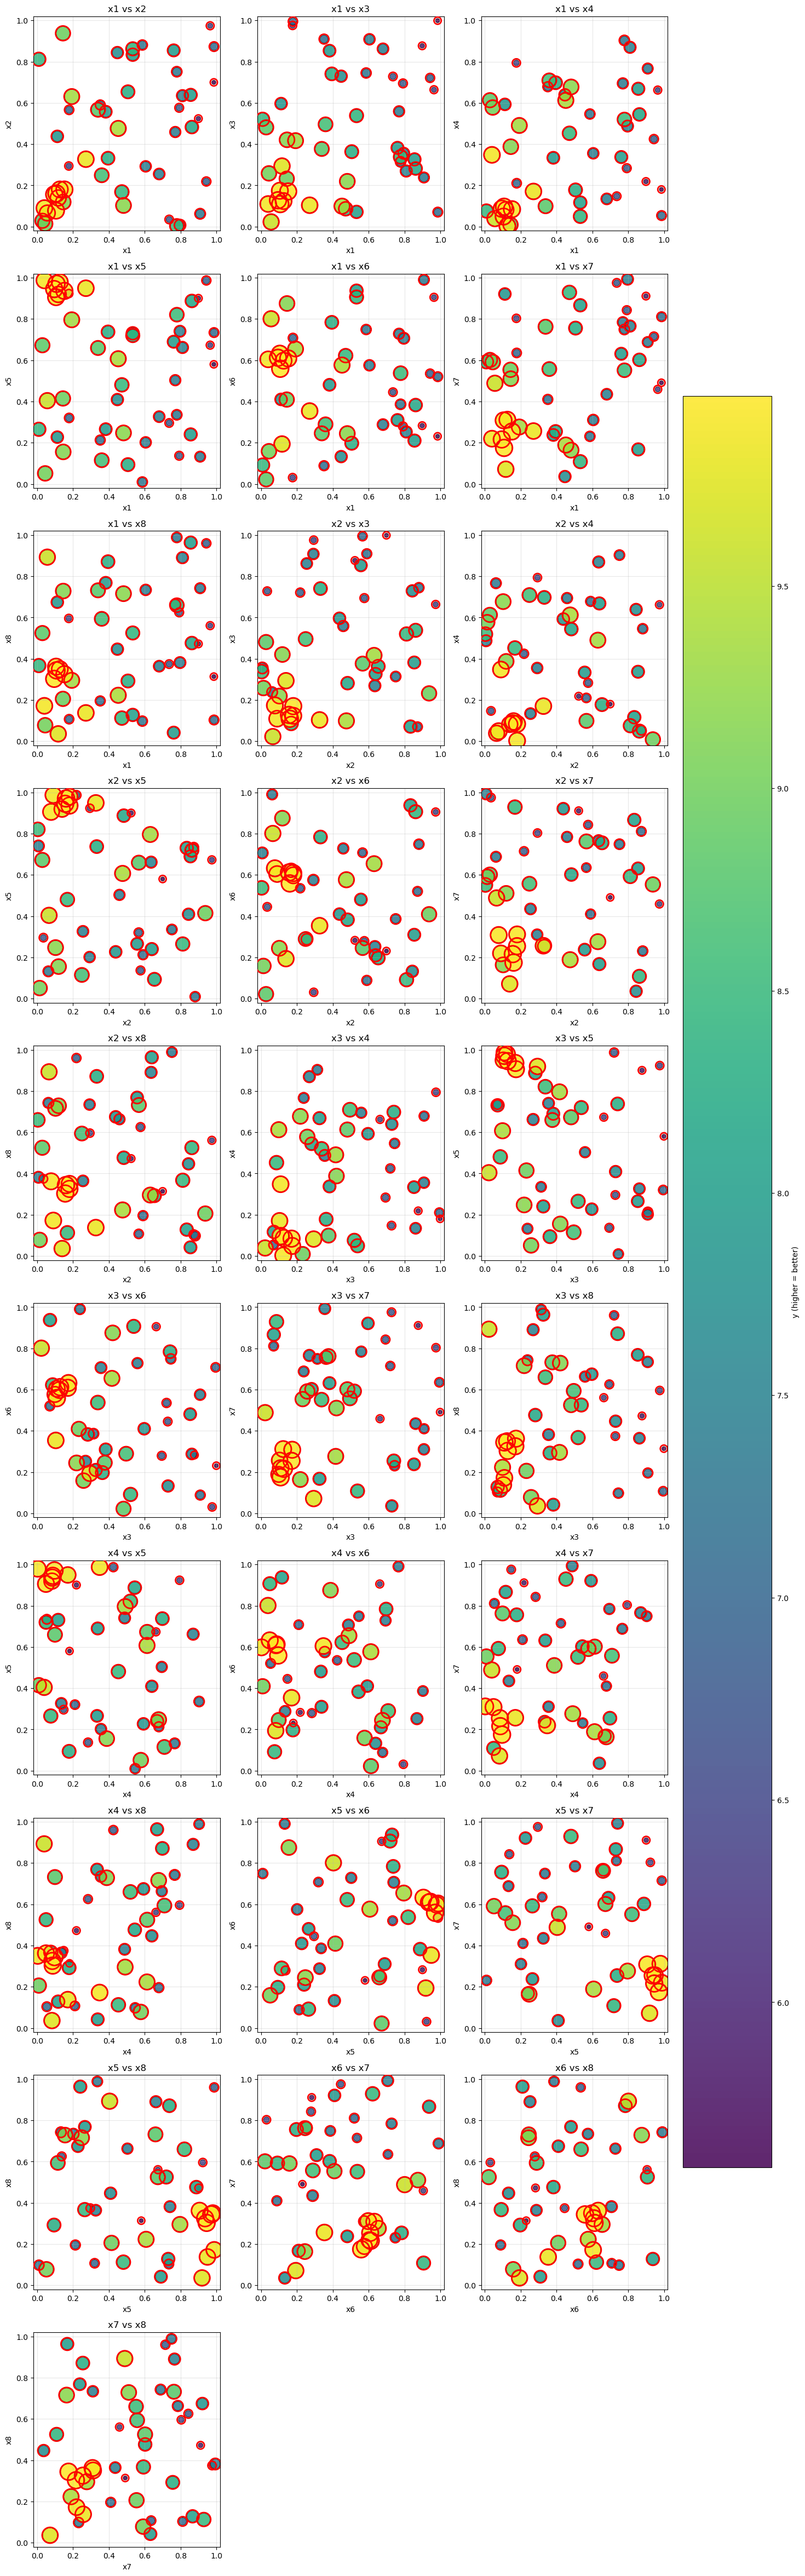

In [4]:
from scipy.stats import rankdata
from itertools import combinations

ridge_idx = np.where(y > 0)[0]   # or however you identify the ridge cluster
fig, axes = plot_nd_projection_matrix(X, y, highlight_idx=ridge_idx)
plt.savefig('./Figures/Function8_projection_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Transform Data

In [5]:
# No transforms applied

y_fit = y

df_y = pd.DataFrame({
    "X1": X[:,0],
    "X2": X[:,1],
    "X3": X[:,2],
    "X4": X[:,3],
    "X5": X[:,4],
    "X6": X[:,5],
    "X7": X[:,6],
    "X8": X[:,7],
    "y": y,
    "y_fit": y_fit
})

output_file = f'./initial_data/{function}/y_transformations.csv'
df_y.to_csv(output_file, index=False)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'function_8 — y_fit progression with running best'}, xlabel='Iteration (submission number)', ylabel='y_fit'>)

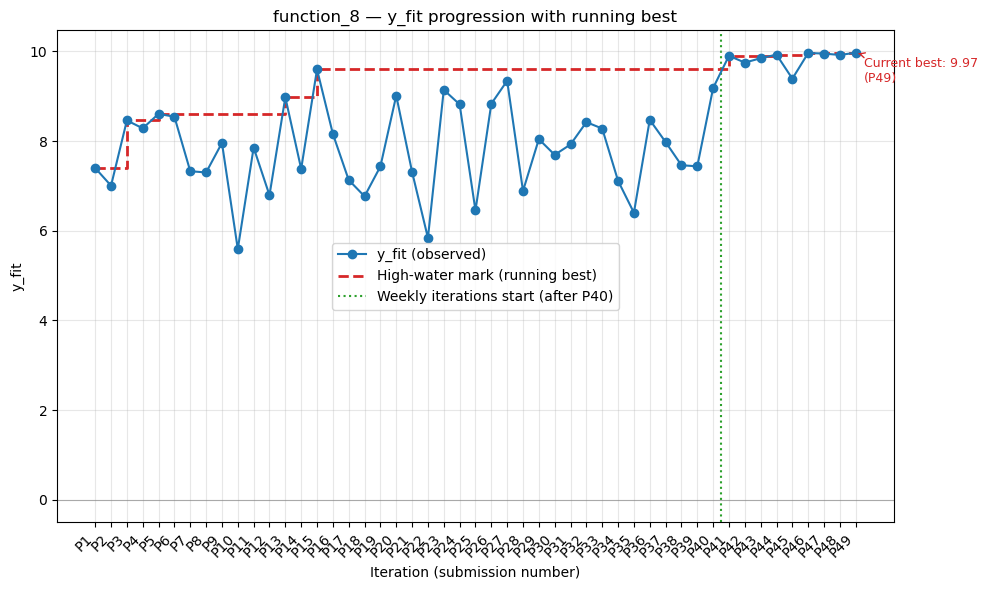

In [6]:
# Point labels and y_fit values to monitor progress
plot_progress(y_fit, labels=None, iteration_start=40, maximize=True,
                   objective_label="y_fit", function_name=function,
                   save_path=None)

## 4. Fit Data to Kernal

In [7]:
# Compare alternative kernels

kernels = {
    'Matern_2.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=2.5),
    'Matern_1.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=1.5),
    'Matern_0.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=0.5),
    'Matern_ARD': ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(8), length_scale_bounds=(0.05, 20), nu=2.5),
    # single scalar — isotropic
    'RBF1':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.3, length_scale_bounds=(0.05, 2.0)),
    'RBF2':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.25, 2.0)), 
    'RBF3':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.01, 10.0)), 
    'RBF4':        ConstantKernel(1.0, (0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.01, 20.0))
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)),
    'RBF5':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=np.ones(X.shape[1]),length_scale_bounds=(0.05, 20.0)), #wk4
    'RBF6':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(0.05, 20.0))
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)),
}

for name, k in kernels.items():
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", category=ConvergenceWarning)
        gpr_test = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=20, random_state=42)
        gpr_test.fit(X, y_fit)
    k_fitted = gpr_test.kernel_
    lml = gpr_test.log_marginal_likelihood_value_
    n_params = len(k_fitted.theta)
    aic = -2 * lml + 2 * n_params
    bic = -2 * lml + n_params * np.log(len(y))
    print(f"{name:12s}  LML={lml:.4f}  AIC={aic:.4f}  BIC={bic:.4f}  kernel={k_fitted}")

Matern_2.5    LML=-7.5334  AIC=19.0667  BIC=22.8503  kernel=1.47**2 * Matern(length_scale=2, nu=2.5)
Matern_1.5    LML=-12.7839  AIC=29.5679  BIC=33.3515  kernel=1.13**2 * Matern(length_scale=2, nu=1.5)
Matern_0.5    LML=-31.7378  AIC=67.4756  BIC=71.2593  kernel=0.83**2 * Matern(length_scale=2, nu=0.5)
Matern_ARD    LML=23.2453  AIC=-28.4907  BIC=-11.4643  kernel=5.43**2 * Matern(length_scale=[4.69, 7.08, 3.84, 6.86, 10.9, 7.05, 4.82, 20], nu=2.5)
RBF1          LML=-10.0852  AIC=24.1705  BIC=27.9541  kernel=2.49**2 * RBF(length_scale=1.77)
RBF2          LML=-10.0852  AIC=24.1705  BIC=27.9541  kernel=2.49**2 * RBF(length_scale=1.77)
RBF3          LML=-10.0852  AIC=24.1705  BIC=27.9541  kernel=2.49**2 * RBF(length_scale=1.77)
RBF4          LML=-10.1219  AIC=26.2438  BIC=31.9193  kernel=2.49**2 * RBF(length_scale=1.77) + WhiteKernel(noise_level=1e-05)
RBF5          LML=13.1815  AIC=-8.3629  BIC=8.6635  kernel=2.63**2 * RBF(length_scale=[1.44, 2.74, 1.24, 1.78, 9.22, 2.17, 1.61, 20])
RBF6

In [8]:
# Fit Gaussian Process
# Select the best kernel for fitting
#selected_kernel = 'RBF5' wk8
selected_kernel = 'Matern_ARD' #wk9

kernel = kernels[selected_kernel]

gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
gpr.fit(X, y_fit)
print(gpr.kernel_)

print(f"LML:       {gpr.log_marginal_likelihood_value_:.4f}")

5.43**2 * Matern(length_scale=[4.69, 7.08, 3.84, 6.86, 10.9, 7.05, 4.82, 20], nu=2.5)
LML:       23.2453


C:\Users\scbar\anaconda3\envs\scipy-clean\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 20.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [9]:
# Prediction Grid - Generate candidates and predict y

n_candidates = 10000
low = np.zeros(X.shape[1])
high = np.ones(X.shape[1])

rng = np.random.default_rng(42)
grid = rng.uniform(
low=low,
high=high,
size=(n_candidates, X.shape[1]))

print("Shape:", grid.shape)
print("Dimensions:", grid.ndim)
print("\nFirst 5 rows:")
print(grid[:5])
    
# GP predictions
mu, sigma = gpr.predict(grid, return_std=True)


Shape: (10000, 8)
Dimensions: 2

First 5 rows:
[[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735 0.97562235
  0.7611397  0.78606431]
 [0.12811363 0.45038594 0.37079802 0.92676499 0.64386512 0.82276161
  0.4434142  0.22723872]
 [0.55458479 0.06381726 0.82763117 0.6316644  0.75808774 0.35452597
  0.97069802 0.89312112]
 [0.7783835  0.19463871 0.466721   0.04380377 0.15428949 0.68304895
  0.74476216 0.96750973]
 [0.32582536 0.37045971 0.46955581 0.18947136 0.12992151 0.47570493
  0.22690935 0.66981399]]


## 5. Define Acquisition Function

In [10]:
 
xi_values = {
    "function_8": 0.1
}

In [11]:
# Expected Improvement acquisition function
y_best = np.max(y_fit)


xi = xi_values.get(function, 0.1)

print(f"Using xi = {xi} for {function}")

improvement = mu - y_best - xi
Z = improvement / sigma

ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
ei[sigma == 0.0] = 0.0

# Pick next point
next_idx = np.argmax(ei)
print("Next Idx: ", next_idx)
next_x = grid[next_idx]

print("Current best y:", y_best)
print("Next point to evaluate:", next_x)
print("Formatted next point to evaluate:", "-".join(f"{x:.6f}" for x in next_x))
print("Expected improvement:", ei[next_idx])

print("Predicted mean:", mu[next_idx])
print("Predicted std:", sigma[next_idx])
print("Improvement:", mu[next_idx] - y_best - xi)

Using xi = 0.1 for function_8
Next Idx:  1265
Current best y: 9.9697337332179
Next point to evaluate: [0.07391263 0.22448648 0.09045841 0.12669943 0.16351654 0.30202943
 0.01101668 0.95014389]
Formatted next point to evaluate: 0.073913-0.224486-0.090458-0.126699-0.163517-0.302029-0.011017-0.950144
Expected improvement: 1.456213452182082e-05
Predicted mean: 9.691002195263456
Predicted std: 0.11474144521912531
Improvement: -0.37873153795444414


In [ ]:
# UCB acquisition function

# ---- ACQUISITION: GP-UCB (replaces EI) ----
kappa = 10
ucb = mu + kappa * sigma
 
next_idx = np.argmax(ucb)
 
print(f"\nUsing kappa = {kappa} for function_8")
print("Next Idx: ", next_idx)
print("Current best y:", y_best)
print("Next point to evaluate:", grid[next_idx])
print("UCB value:", ucb[next_idx])
print("Predicted mean:", mu[next_idx])
print("Predicted std:", sigma[next_idx])

In [12]:
#LHS function 8
from scipy.stats.qmc import LatinHypercube

x_best = X[np.argmax(y)]  
print("x_best index:", np.argmax(y))
#r = 0.10
r = 0.06 #wk9 - shrunk from 0.10 — TuRBO failure #2 (P47 near-tie, P48 miss)

bounds_low  = np.array([max(0.0, x_best[i] - r) for i in range(8)]) #wk8 changed 0.05 to 0
bounds_high = np.array([min(1.0, x_best[i] + r) for i in range(8)]) #wk8 changed 0.95 to 1.0

# Key constraints
#bounds_high[0] = 0.12   # x1 ceiling
#bounds_high[2] = 0.15   # x3 ceiling
bounds_low[4]  = 0.90   # x5 floor
bounds_low[3]  = 0.05   # x4 floor — RESTORED wk9: P48 (x4=0.003) missed at 6.6 sigma
#bounds_high[6] = 0.25   # x7 ceiling

print("Bounds:", list(zip(bounds_low.round(3), bounds_high.round(3))))

sampler = LatinHypercube(d=8, seed=42)
lhs = sampler.random(n=100)
candidates = bounds_low + lhs * (bounds_high - bounds_low)

mu_c, _ = gpr.predict(candidates, return_std=True)

dmin = cdist(candidates, X).min(axis=1)
valid = dmin > 0.05

best_idx = np.argmax(mu_c[valid])
next_x = candidates[valid][best_idx]

print("Using Kernel: ", kernel)
print("Selected kernel: ", selected_kernel)
print(gpr.kernel_)
print("Next point:", next_x)
print("r radius:", r)
print("Formatted:", "-".join(f"{x:.6f}" for x in next_x))
print("mu:", mu_c[valid][best_idx])


x_best index: 48
Bounds: [(np.float64(0.048), np.float64(0.168)), (np.float64(0.101), np.float64(0.221)), (np.float64(0.049), np.float64(0.169)), (np.float64(0.05), np.float64(0.156)), (np.float64(0.9), np.float64(1.0)), (np.float64(0.499), np.float64(0.619)), (np.float64(0.115), np.float64(0.235)), (np.float64(0.284), np.float64(0.404))]
Using Kernel:  1**2 * Matern(length_scale=[1, 1, 1, 1, 1, 1, 1, 1], nu=2.5)
Selected kernel:  Matern_ARD
5.43**2 * Matern(length_scale=[4.69, 7.08, 3.84, 6.86, 10.9, 7.05, 4.82, 20], nu=2.5)
Next point: [0.12599906 0.16633271 0.13962548 0.14677268 0.94074574 0.57205545
 0.15873265 0.35409489]
r radius: 0.06
Formatted: 0.125999-0.166333-0.139625-0.146773-0.940746-0.572055-0.158733-0.354095
mu: 9.971927532841441


## 6. Plots for Uncertainty and Signal Strength 

In [ ]:
# --- Plot ---

